In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
applications = pd.read_csv("applications_clean.csv")
candidates = pd.read_csv("candidates_clean.csv")
companies  = pd.read_csv("companies_clean.csv")
interviews = pd.read_csv("interviews_clean.csv")
jobs      = pd.read_csv("jobs_clean.csv")
offers    = pd.read_csv("offers_clean.csv")

In [5]:
print("Companies:", companies.shape)
print("Candidates:", candidates.shape)
print("Jobs:", jobs.shape)
print("Applications:", applications.shape)
print("Interviews:", interviews.shape)
print("Offers:", offers.shape)

Companies: (320, 5)
Candidates: (9000, 7)
Jobs: (2000, 17)
Applications: (15000, 11)
Interviews: (7196, 5)
Offers: (938, 7)


In [7]:
# Check basic information about each dataset

datasets = {
    "Companies": companies,
    "Candidates": candidates,
    "Jobs": jobs,
    "Applications": applications,
    "Interviews": interviews,
    "Offers": offers
}

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    print("Rows and Columns:", df.shape)
    print("\nData Types:")
    print(df.dtypes)


Companies
Rows and Columns: (320, 5)

Data Types:
company_id       int64
company_name    object
industry        object
company_size    object
hq_city         object
dtype: object

Candidates
Rows and Columns: (9000, 7)

Data Types:
candidate_id          int64
candidate_name       object
years_experience      int64
current_city         object
top_skill_area       object
summary              object
experience_bucket    object
dtype: object

Jobs
Rows and Columns: (2000, 17)

Data Types:
job_id                 int64
company_id             int64
posted_at             object
title                 object
role_family           object
level                 object
location_type         object
employment_type       object
salary_low             int64
salary_high            int64
status                object
salary_midpoint      float64
posted_date           object
posted_month           int64
posted_year            int64
posted_month_year     object
salary_range           int64
dtype: object

A

In [9]:
# Statistical summary of numerical columns

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    display(df.describe())


Companies


,company_id
count,320.000000
mean,160.500000
std,92.520268
min,1.000000
25%,80.750000
50%,160.500000
75%,240.250000
max,320.000000



Candidates


,candidate_id,years_experience
count,9000.000000,9000.000000
mean,4500.500000,8.546333
std,2598.220545,5.219556
min,1.000000,0.000000
25%,2250.750000,4.000000
50%,4500.500000,9.000000
75%,6750.250000,13.000000
max,9000.000000,17.000000



Jobs


...

,application_id,job_id,candidate_id,score,application_month,application_year
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,1006.193133,4487.445933,0.666598,6.176333,2024.542267
std,4330.271354,578.944829,2595.149489,0.182840,3.343908,0.535630
min,1.000000,1.000000,1.000000,0.350000,1.000000,2024.000000
25%,3750.750000,508.750000,2240.750000,0.508000,3.000000,2024.000000
50%,7500.500000,1013.000000,4488.500000,0.668000,6.000000,2025.000000
75%,11250.250000,1510.000000,6734.000000,0.827000,9.000000,2025.000000
max,15000.000000,2000.000000,9000.000000,0.980000,12.000000,2026.000000



Interviews


,interview_id,application_id
count,7196.000000,7196.000000
mean,3598.500000,7600.042524
std,2077.450601,4316.115925
min,1.000000,2.000000
25%,1799.750000,3832.000000
50%,3598.500000,7817.500000
75%,5397.250000,11285.000000
max,7196.000000,14990.000000



Offers


,offer_id,application_id,base_salary,accepted
count,938.000000,938.000000,938.000000,938.000000
mean,469.500000,7580.720682,129879.686567,0.745203
std,270.921575,4364.015156,35859.026407,0.435980
min,1.000000,8.000000,61321.000000,0.000000
25%,235.250000,3756.000000,101857.000000,0.000000
50%,469.500000,7832.500000,126487.500000,1.000000
75%,703.750000,11248.250000,150348.500000,1.000000
max,938.000000,14984.000000,240017.000000,1.000000


## Univariate Analysis

count    9000.000000
mean        8.546333
std         5.219556
min         0.000000
25%         4.000000
50%         9.000000
75%        13.000000
max        17.000000
Name: years_experience, dtype: float64


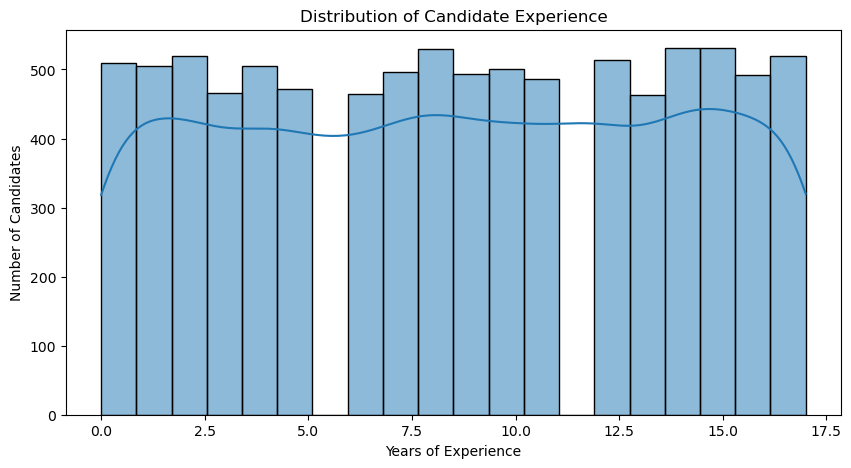

In [12]:
# Candidate Experience Distribution

print(candidates['years_experience'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    candidates['years_experience'],
    bins=20,
    kde=True
)

plt.title('Distribution of Candidate Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Number of Candidates')
plt.show()

experience_bucket
10+ years     3537
6-10 years    2485
0-2 years     1535
3-5 years     1443
Name: count, dtype: int64


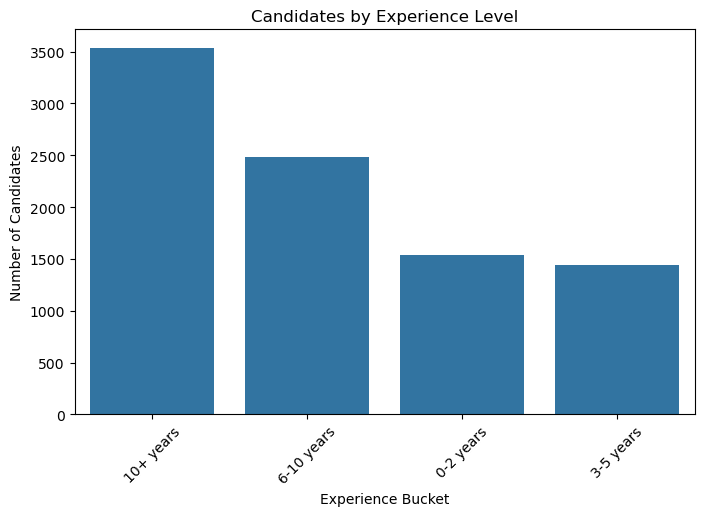

In [14]:
# Experience Bucket Distribution

experience_counts = candidates['experience_bucket'].value_counts()

print(experience_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=candidates,
    x='experience_bucket',
    order=experience_counts.index
)

plt.title('Candidates by Experience Level')
plt.xlabel('Experience Bucket')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=45)
plt.show()

count    15000.000000
mean         0.666598
std          0.182840
min          0.350000
25%          0.508000
50%          0.668000
75%          0.827000
max          0.980000
Name: score, dtype: float64


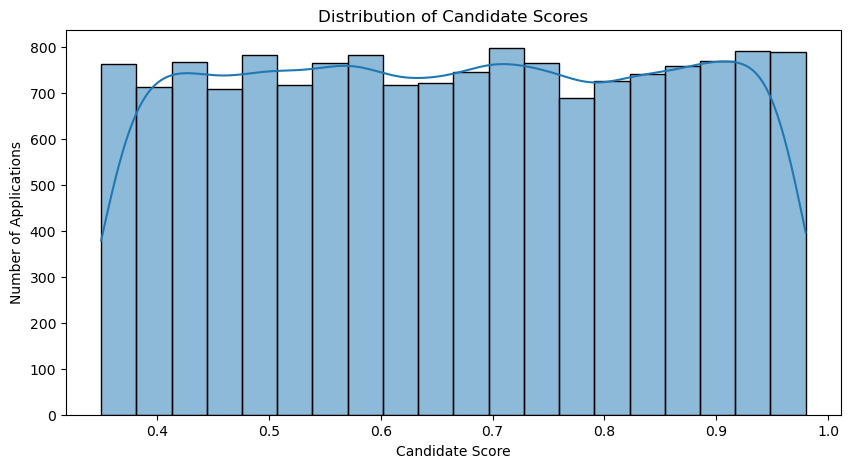

In [18]:
# Experience Bucket Distribution

# Candidate Score Distribution

print(applications['score'].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    applications['score'],
    bins=20,
    kde=True
)

plt.title('Distribution of Candidate Scores')
plt.xlabel('Candidate Score')
plt.ylabel('Number of Applications')

plt.show()

In [20]:
# Candidate Score Statistics

print("Mean Score:", round(applications['score'].mean(), 2))
print("Median Score:", round(applications['score'].median(), 2))
print("Minimum Score:", applications['score'].min())
print("Maximum Score:", applications['score'].max())

Mean Score: 0.67
Median Score: 0.67
Minimum Score: 0.35
Maximum Score: 0.98


count       938.000000
mean     129879.686567
std       35859.026407
min       61321.000000
25%      101857.000000
50%      126487.500000
75%      150348.500000
max      240017.000000
Name: base_salary, dtype: float64


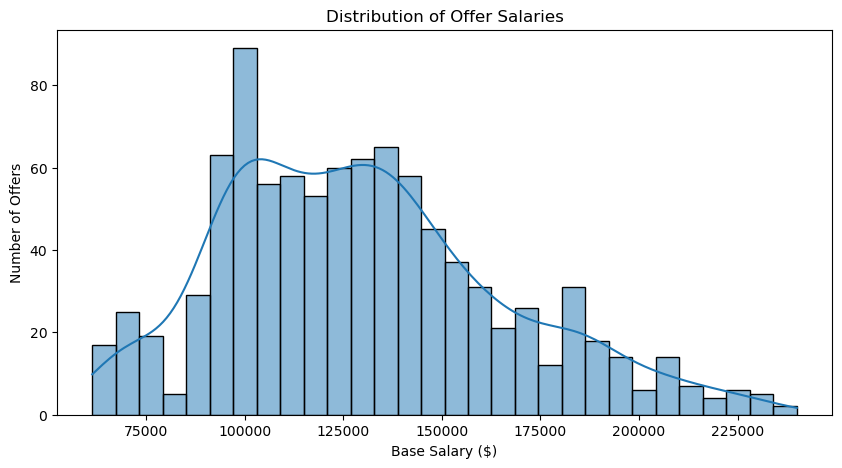

In [22]:
# Offer Salary Distribution

print(offers['base_salary'].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    offers['base_salary'],
    bins=30,
    kde=True
)

plt.title('Distribution of Offer Salaries')
plt.xlabel('Base Salary ($)')
plt.ylabel('Number of Offers')

plt.show()

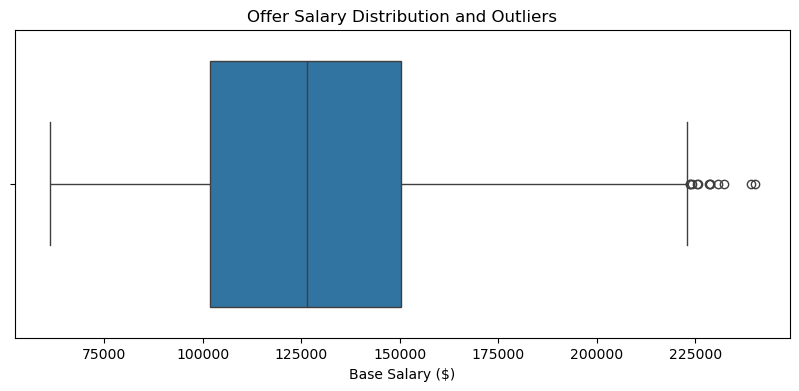

In [24]:
# Offer Salary Boxplot

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=offers['base_salary']
)

plt.title('Offer Salary Distribution and Outliers')
plt.xlabel('Base Salary ($)')

plt.show()

In [26]:
# Salary Statistics

print("Average Salary:", round(offers['base_salary'].mean(), 2))
print("Median Salary:", round(offers['base_salary'].median(), 2))
print("Minimum Salary:", offers['base_salary'].min())
print("Maximum Salary:", offers['base_salary'].max())

Average Salary: 129879.69
Median Salary: 126487.5
Minimum Salary: 61321
Maximum Salary: 240017


count      2000.000000
mean     130496.500000
std       35039.897045
min       65000.000000
25%      101000.000000
50%      124750.000000
75%      149000.000000
max      225000.000000
Name: salary_midpoint, dtype: float64


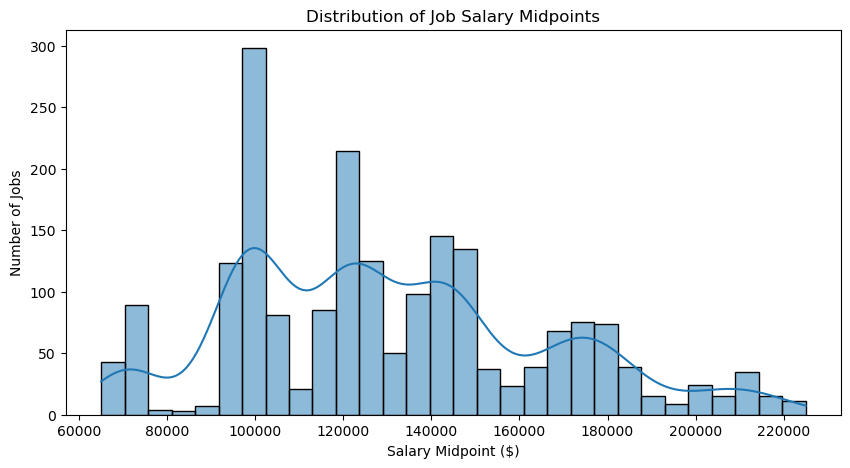

In [28]:
# Job Salary Midpoint Distribution

print(jobs['salary_midpoint'].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    jobs['salary_midpoint'],
    bins=30,
    kde=True
)

plt.title('Distribution of Job Salary Midpoints')
plt.xlabel('Salary Midpoint ($)')
plt.ylabel('Number of Jobs')

plt.show()

count     2000.000000
mean     25302.000000
std       9589.722488
min       6000.000000
25%      18000.000000
50%      24000.000000
75%      31000.000000
max      62000.000000
Name: salary_range, dtype: float64


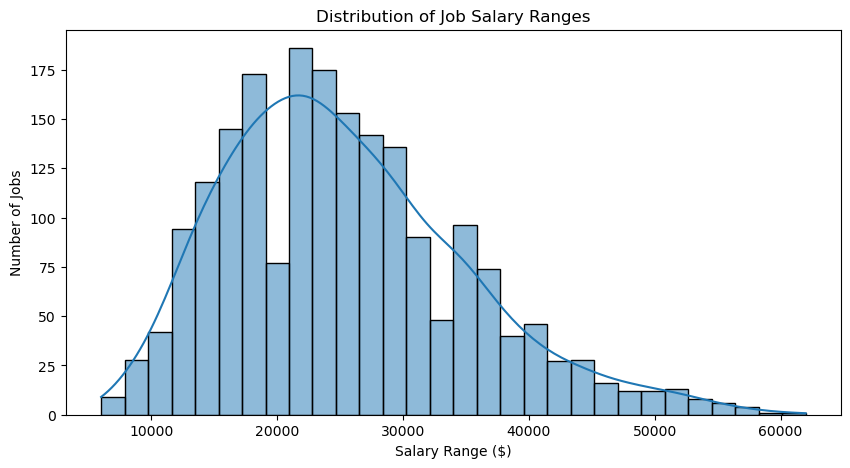

In [30]:
# Job Salary Range Distribution

print(jobs['salary_range'].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    jobs['salary_range'],
    bins=30,
    kde=True
)

plt.title('Distribution of Job Salary Ranges')
plt.xlabel('Salary Range ($)')
plt.ylabel('Number of Jobs')

plt.show()

In [32]:
# Salary Summary

print("Average Salary Midpoint:",
      round(jobs['salary_midpoint'].mean(), 2))

print("Median Salary Midpoint:",
      round(jobs['salary_midpoint'].median(), 2))

print("Minimum Salary Midpoint:",
      jobs['salary_midpoint'].min())

print("Maximum Salary Midpoint:",
      jobs['salary_midpoint'].max())

Average Salary Midpoint: 130496.5
Median Salary Midpoint: 124750.0
Minimum Salary Midpoint: 65000.0
Maximum Salary Midpoint: 225000.0


role_family
operations          991
engineering         425
data                302
product             128
customer_success     77
sales                77
Name: count, dtype: int64


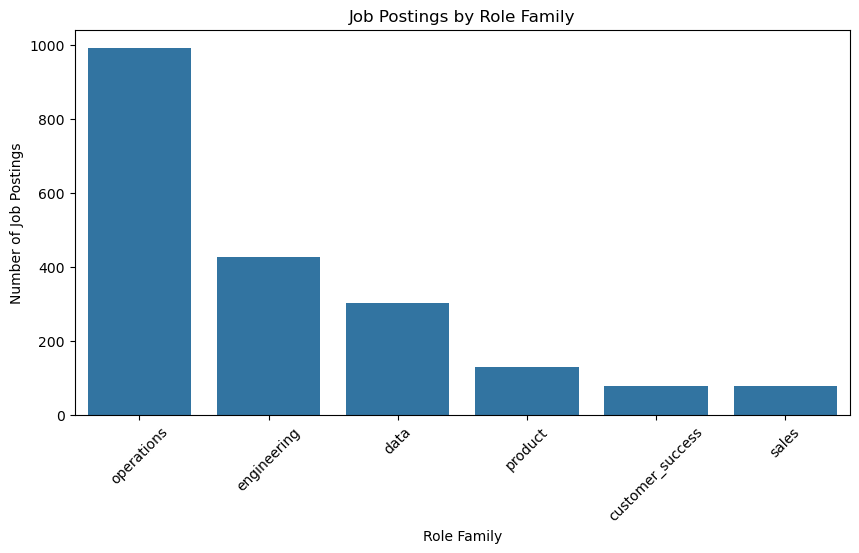

In [34]:
# Role Family Distribution

role_counts = jobs['role_family'].value_counts()

print(role_counts)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=jobs,
    x='role_family',
    order=role_counts.index
)

plt.title('Job Postings by Role Family')
plt.xlabel('Role Family')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)

plt.show()

level
senior    748
mid       739
lead      260
junior    253
Name: count, dtype: int64


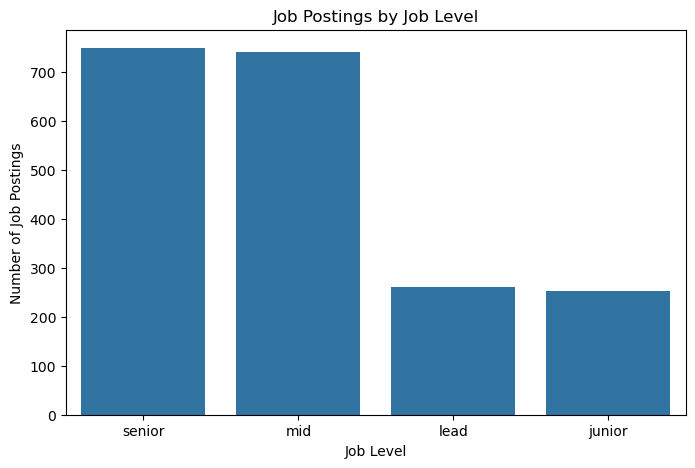

In [36]:
# Job Level Distribution

level_counts = jobs['level'].value_counts()

print(level_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=jobs,
    x='level',
    order=level_counts.index
)

plt.title('Job Postings by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Number of Job Postings')

plt.show()

location_type
remote    860
hybrid    692
onsite    448
Name: count, dtype: int64


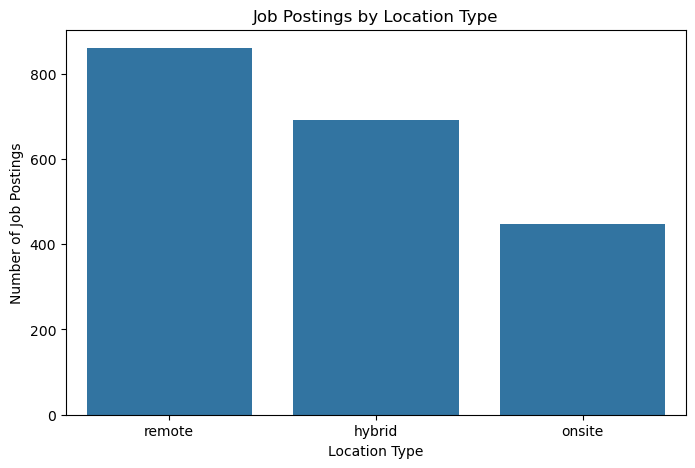

In [38]:
# Location Type Distribution

location_counts = jobs['location_type'].value_counts()

print(location_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=jobs,
    x='location_type',
    order=location_counts.index
)

plt.title('Job Postings by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Number of Job Postings')

plt.show()

source
job_board    7094
referral     2694
linkedin     2648
outbound     1333
recruiter    1231
Name: count, dtype: int64


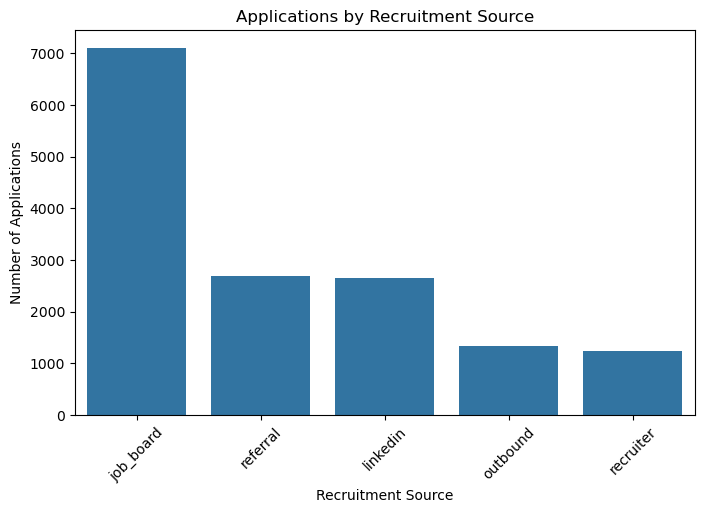

In [40]:
# Application Source Distribution

source_counts = applications['source'].value_counts()

print(source_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=applications,
    x='source',
    order=source_counts.index
)

plt.title('Applications by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)

plt.show()

## Bivariate Analysis

In [43]:
# Create recruitment outcome flags

applications['interviewed'] = applications['application_id'].isin(
    interviews['application_id']
)

applications['offered'] = applications['application_id'].isin(
    offers['application_id']
)

applications[['score', 'interviewed', 'offered']].head()

,score,interviewed,offered
0,0.920,False,False
1,0.525,True,False
2,0.474,False,False
3,0.587,True,False
4,0.403,False,False


In [45]:
# Average candidate score by recruitment outcome

score_analysis = applications.groupby(
    ['interviewed', 'offered']
)['score'].agg(['count', 'mean', 'median']).reset_index()

print(score_analysis)

   interviewed  offered  count      mean  median
0        False    False  11430  0.667158  0.6690
1         True    False   2632  0.661618  0.6600
2         True     True    938  0.673754  0.6725


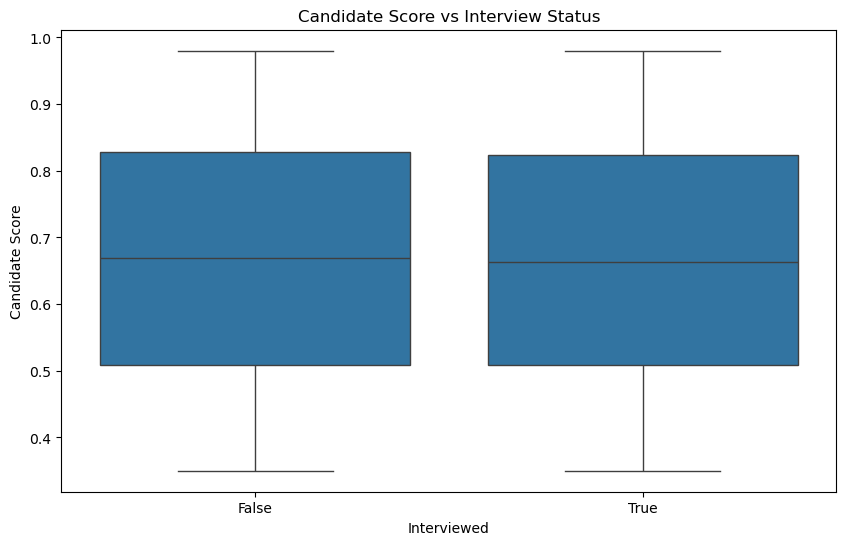

In [47]:
# Candidate Score vs Recruitment Outcome

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=applications,
    x='interviewed',
    y='score'
)

plt.title('Candidate Score vs Interview Status')
plt.xlabel('Interviewed')
plt.ylabel('Candidate Score')

plt.show()

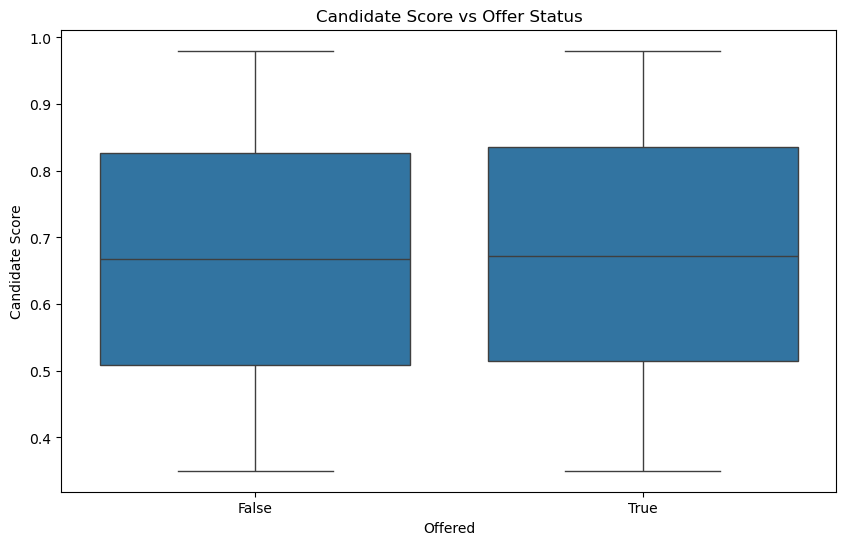

In [49]:
# Candidate Score vs Offer Status

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=applications,
    x='offered',
    y='score'
)

plt.title('Candidate Score vs Offer Status')
plt.xlabel('Offered')
plt.ylabel('Candidate Score')

plt.show()

In [51]:
# Merge candidate experience with application score

experience_score = applications.merge(
    candidates[['candidate_id', 'years_experience']],
    on='candidate_id',
    how='left'
)

experience_score[['years_experience', 'score']].head()

,years_experience,score
0,10,0.920
1,17,0.525
2,4,0.474
3,11,0.587
4,11,0.403


In [53]:
# Correlation between experience and candidate score

correlation = experience_score[
    ['years_experience', 'score']
].corr()

print(correlation)

                  years_experience     score
years_experience          1.000000  0.010679
score                     0.010679  1.000000


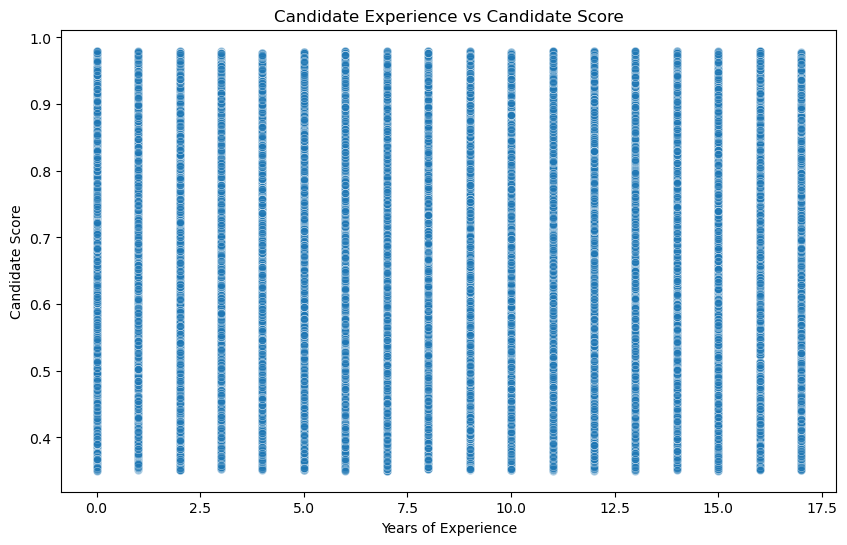

In [55]:
# Experience vs Candidate Score

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=experience_score,
    x='years_experience',
    y='score',
    alpha=0.5
)

plt.title('Candidate Experience vs Candidate Score')
plt.xlabel('Years of Experience')
plt.ylabel('Candidate Score')

plt.show()

In [57]:
# Average candidate score by experience bucket

experience_score = experience_score.merge(
    candidates[['candidate_id', 'experience_bucket']],
    on='candidate_id',
    how='left'
)

score_by_experience = (
    experience_score
    .groupby('experience_bucket')['score']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

print(score_by_experience)

  experience_bucket  count      mean  median
0         0-2 years   2577  0.661986   0.661
1         10+ years   5918  0.669252   0.670
2         3-5 years   2413  0.670663   0.677
3        6-10 years   4092  0.663268   0.665


In [59]:
# Average Salary by Job Level

salary_by_level = (
    jobs.groupby('level')['salary_midpoint']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(salary_by_level)

    level  count           mean    median       min       max
1    lead    260  174186.538462  152500.0  135500.0  225000.0
3  senior    748  144735.294118  127250.0  110500.0  189500.0
2     mid    739  116319.350474  102500.0   89000.0  153500.0
0  junior    253   84911.067194   74500.0   65000.0  111000.0


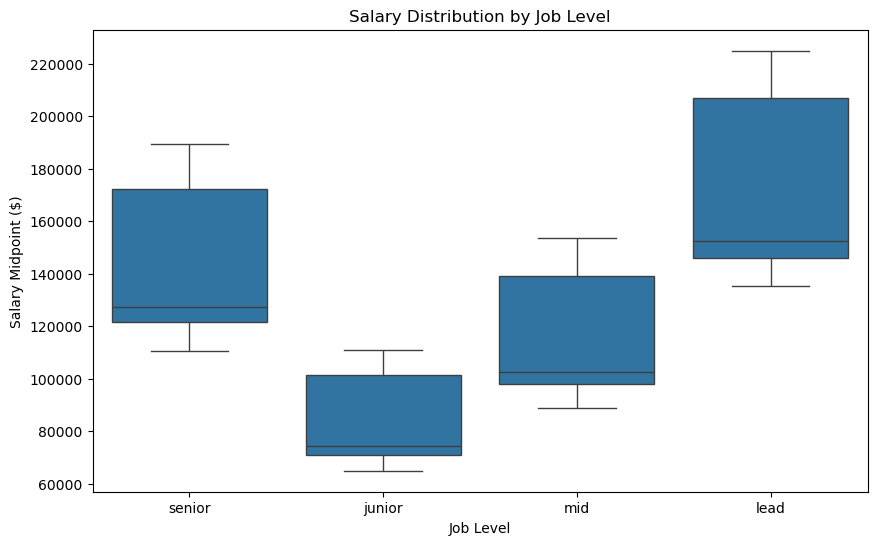

In [61]:
# Job Level vs Salary

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=jobs,
    x='level',
    y='salary_midpoint'
)

plt.title('Salary Distribution by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Salary Midpoint ($)')

plt.show()

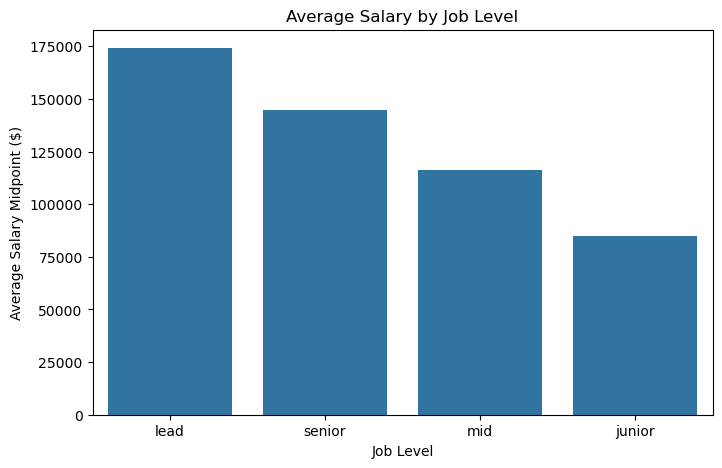

In [63]:
# Average salary by job level

plt.figure(figsize=(8, 5))

sns.barplot(
    data=salary_by_level,
    x='level',
    y='mean'
)

plt.title('Average Salary by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Average Salary Midpoint ($)')

plt.show()

In [65]:
# Salary by Role Family

salary_by_role = (
    jobs.groupby('role_family')['salary_midpoint']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(salary_by_role)

        role_family  count           mean    median       min       max
1              data    302  164428.807947  174500.0  100000.0  225000.0
2       engineering    425  153808.235294  145000.0   95000.0  218000.0
4           product    128  148738.281250  158250.0   90000.0  203000.0
5             sales     77  125227.272727  116500.0   76000.0  171000.0
3        operations    991  110513.622603  116000.0   67000.0  153500.0
0  customer_success     77  100870.129870   97000.0   65000.0  146000.0


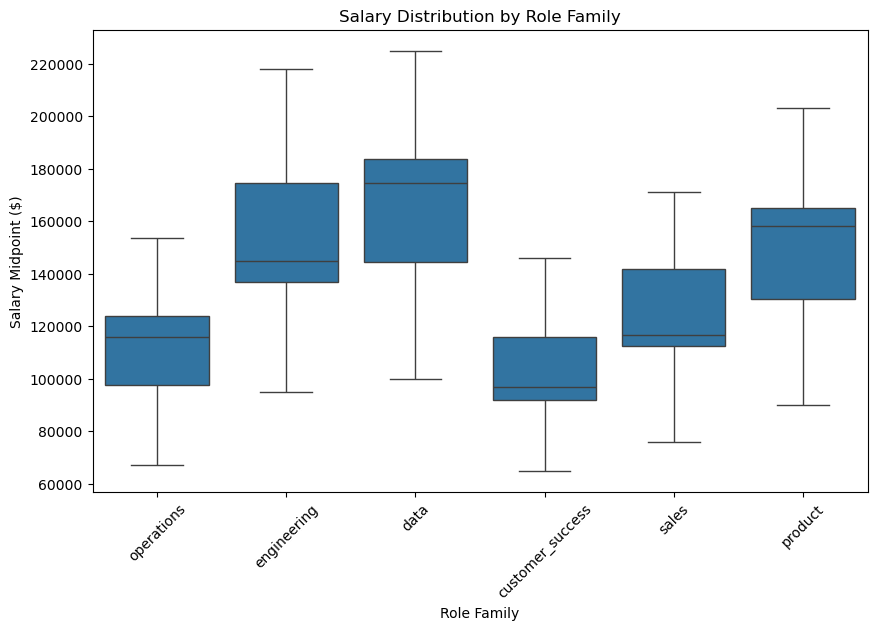

In [67]:
# Role Family vs Salary

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=jobs,
    x='role_family',
    y='salary_midpoint'
)

plt.title('Salary Distribution by Role Family')
plt.xlabel('Role Family')
plt.ylabel('Salary Midpoint ($)')
plt.xticks(rotation=45)

plt.show()

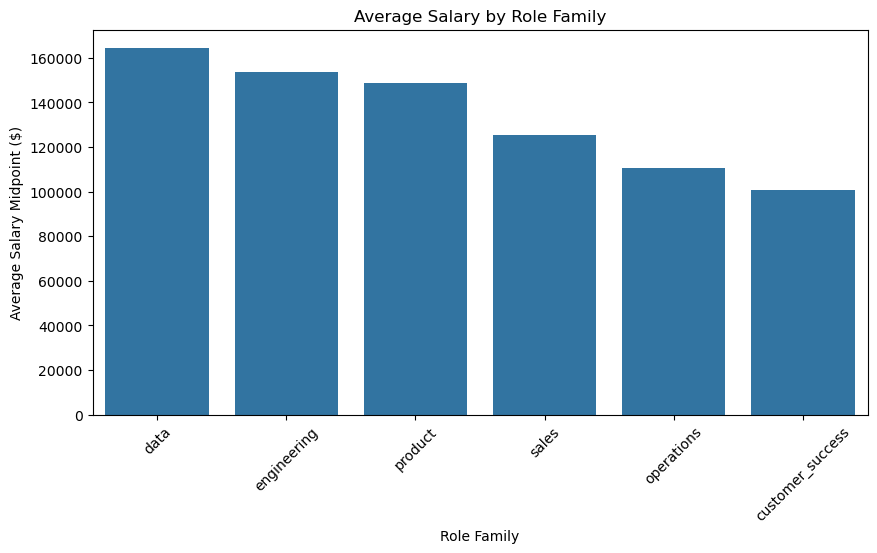

In [69]:
# Average Salary by Role Family

plt.figure(figsize=(10, 5))

sns.barplot(
    data=salary_by_role,
    x='role_family',
    y='mean'
)

plt.title('Average Salary by Role Family')
plt.xlabel('Role Family')
plt.ylabel('Average Salary Midpoint ($)')
plt.xticks(rotation=45)

plt.show()

In [71]:
# Candidate Score by Recruitment Source

score_by_source = (
    applications.groupby('source')['score']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(score_by_source)

      source  count      mean  median   min    max
3  recruiter   1231  0.673714  0.6870  0.35  0.979
0  job_board   7094  0.667165  0.6680  0.35  0.980
4   referral   2694  0.667110  0.6665  0.35  0.980
2   outbound   1333  0.664899  0.6710  0.35  0.980
1   linkedin   2648  0.662108  0.6570  0.35  0.980


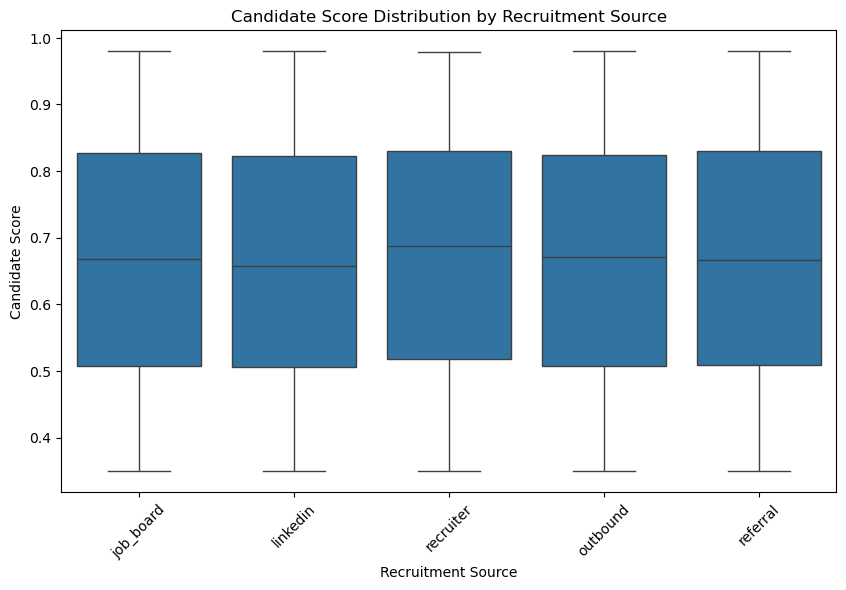

In [73]:
# Candidate Score Distribution by Recruitment Source

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=applications,
    x='source',
    y='score'
)

plt.title('Candidate Score Distribution by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Candidate Score')
plt.xticks(rotation=45)

plt.show()

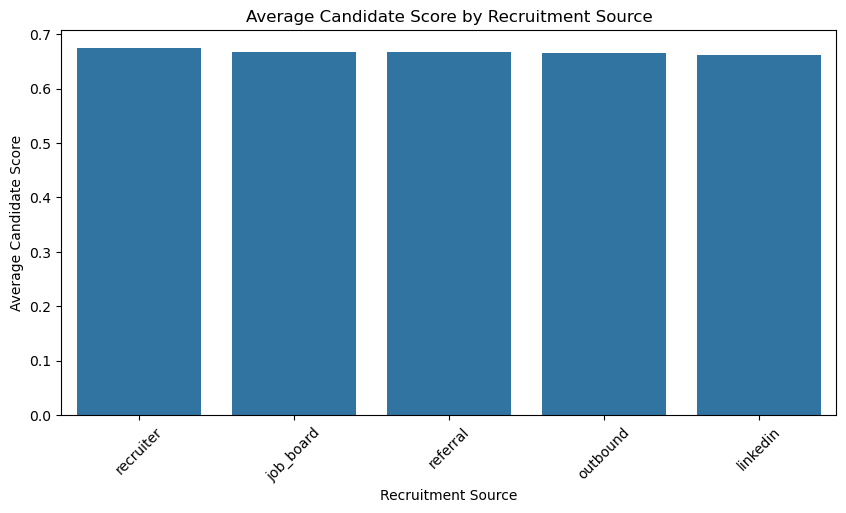

In [75]:
# Average Candidate Score by Source

plt.figure(figsize=(10, 5))

sns.barplot(
    data=score_by_source,
    x='source',
    y='mean'
)

plt.title('Average Candidate Score by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Average Candidate Score')
plt.xticks(rotation=45)

plt.show()

In [77]:
# Recruitment Source Performance

source_performance = applications.groupby('source').agg(
    applications=('application_id', 'nunique'),
    interviewed=('interviewed', 'sum'),
    offered=('offered', 'sum')
).reset_index()

source_performance['interview_rate'] = (
    source_performance['interviewed']
    / source_performance['applications'] * 100
)

source_performance['offer_rate'] = (
    source_performance['offered']
    / source_performance['applications'] * 100
)

source_performance = source_performance.sort_values(
    'offer_rate',
    ascending=False
)

print(source_performance)

      source  applications  interviewed  offered  interview_rate  offer_rate
3  recruiter          1231          295       84       23.964257    6.823721
0  job_board          7094         1764      459       24.866084    6.470257
2   outbound          1333          281       84       21.080270    6.301575
1   linkedin          2648          615      159       23.225076    6.004532
4   referral          2694          615      152       22.828508    5.642168


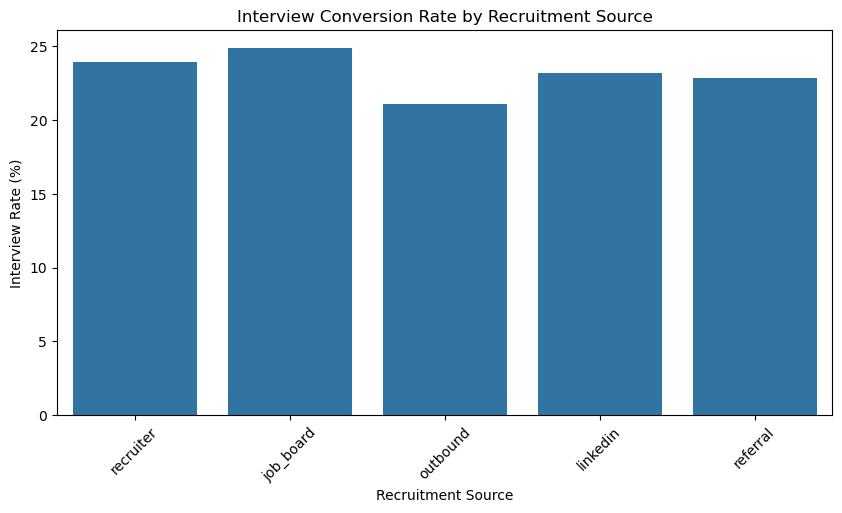

In [79]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=source_performance,
    x='source',
    y='interview_rate'
)

plt.title('Interview Conversion Rate by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Interview Rate (%)')
plt.xticks(rotation=45)

plt.show()

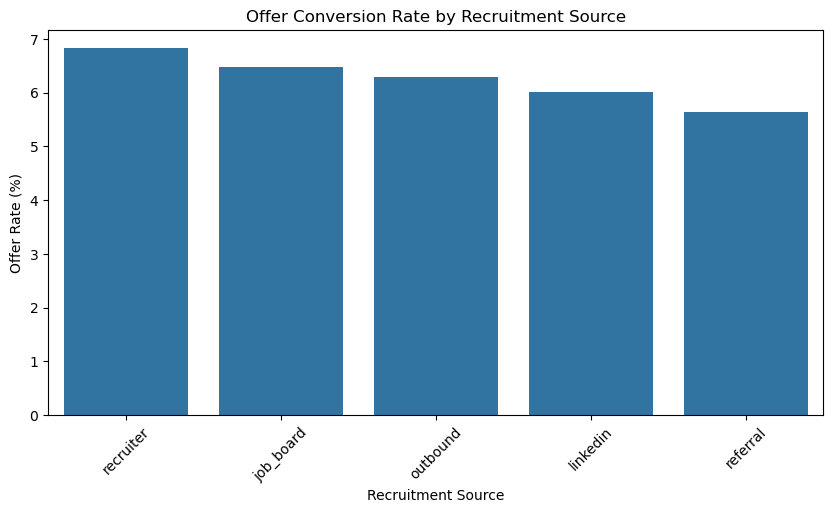

In [81]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=source_performance,
    x='source',
    y='offer_rate'
)

plt.title('Offer Conversion Rate by Recruitment Source')
plt.xlabel('Recruitment Source')
plt.ylabel('Offer Rate (%)')
plt.xticks(rotation=45)

plt.show()

## Multivariate Analysis.

In [84]:
# Merge candidate experience with application data

candidate_analysis = applications.merge(
    candidates[
        ['candidate_id', 'years_experience', 'experience_bucket']
    ],
    on='candidate_id',
    how='left'
)

candidate_analysis[
    ['years_experience', 'score', 'offered']
].head()

,years_experience,score,offered
0,10,0.920,False
1,17,0.525,False
2,4,0.474,False
3,11,0.587,False
4,11,0.403,False


In [88]:
# Create experience groups

candidate_analysis['experience_group'] = pd.cut(
    candidate_analysis['years_experience'],
    bins=[-1, 2, 5, 10, np.inf],
    labels=['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']
)

In [90]:
# Create score groups

candidate_analysis['score_group'] = pd.cut(
    candidate_analysis['score'],
    bins=[0, 0.60, 0.80, 1.00],
    labels=['Low Score', 'Medium Score', 'High Score'],
    include_lowest=True
)

In [92]:
# Experience + Score vs Offer Rate

experience_score_offer = (
    candidate_analysis
    .groupby(['experience_group', 'score_group'], observed=True)
    .agg(
        applications=('application_id', 'nunique'),
        offers=('offered', 'sum')
    )
    .reset_index()
)

experience_score_offer['offer_rate'] = (
    experience_score_offer['offers']
    / experience_score_offer['applications'] * 100
)

print(experience_score_offer)

   experience_group   score_group  applications  offers  offer_rate
0         0-2 Years     Low Score          1052      70    6.653992
1         0-2 Years  Medium Score           794      54    6.801008
2         0-2 Years    High Score           731      48    6.566347
3         3-5 Years     Low Score           932      56    6.008584
4         3-5 Years  Medium Score           769      45    5.851756
5         3-5 Years    High Score           712      50    7.022472
6        6-10 Years     Low Score          1639     103    6.284320
7        6-10 Years  Medium Score          1306      80    6.125574
8        6-10 Years    High Score          1147      70    6.102877
9         10+ Years     Low Score          2348     139    5.919932
10        10+ Years  Medium Score          1816     107    5.892070
11        10+ Years    High Score          1754     116    6.613455


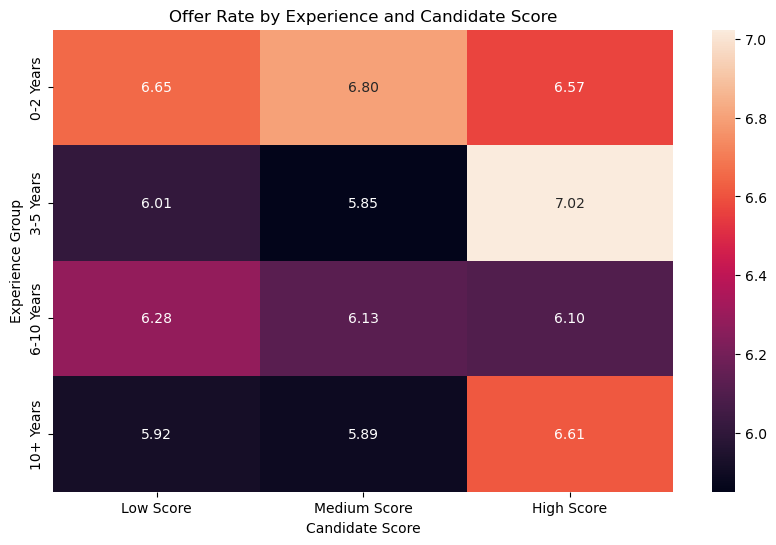

In [94]:
# Experience + Score vs Offer Rate

pivot_data = experience_score_offer.pivot(
    index='experience_group',
    columns='score_group',
    values='offer_rate'
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.2f'
)

plt.title('Offer Rate by Experience and Candidate Score')
plt.xlabel('Candidate Score')
plt.ylabel('Experience Group')

plt.show()

In [96]:
# Salary by Role Family and Job Level

salary_multivariate = (
    jobs.groupby(['role_family', 'level'])['salary_midpoint']
    .agg(['count', 'mean', 'median'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(salary_multivariate)

         role_family   level  count           mean    median
5               data    lead     47  215319.148936  214500.0
9        engineering    lead     51  205088.235294  204500.0
17           product    lead     18  194583.333333  195000.0
7               data  senior    112  181209.821429  181500.0
11       engineering  senior    154  172490.259740  172500.0
21             sales    lead      9  165166.666667  165500.0
19           product  senior     56  161455.357143  161000.0
13        operations    lead    130  146338.461538  146500.0
6               data     mid    103  146043.689320  146000.0
23             sales  senior     25  140520.000000  141500.0
1   customer_success    lead      5  139200.000000  138500.0
10       engineering     mid    161  139059.006211  139000.0
18           product     mid     39  130448.717949  131000.0
15        operations  senior    370  122301.351351  122250.0
3   customer_success  senior     31  116032.258065  116000.0
22             sales    

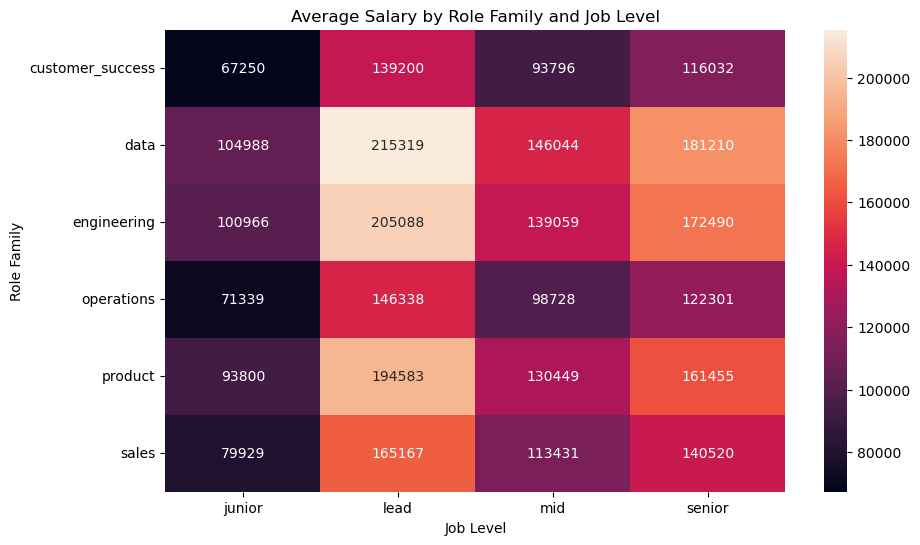

In [98]:
# Average Salary by Role Family and Job Level

salary_pivot = jobs.pivot_table(
    index='role_family',
    columns='level',
    values='salary_midpoint',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    salary_pivot,
    annot=True,
    fmt='.0f'
)

plt.title('Average Salary by Role Family and Job Level')
plt.xlabel('Job Level')
plt.ylabel('Role Family')

plt.show()

In [100]:
# Role Family Recruitment Performance

role_performance = jobs.merge(
    applications[
        ['application_id', 'job_id', 'interviewed', 'offered']
    ],
    on='job_id',
    how='left'
)

role_performance_summary = (
    role_performance
    .groupby('role_family')
    .agg(
        applications=('application_id', 'nunique'),
        interviewed=('interviewed', 'sum'),
        offers=('offered', 'sum')
    )
    .reset_index()
)

role_performance_summary['interview_rate'] = (
    role_performance_summary['interviewed']
    / role_performance_summary['applications'] * 100
)

role_performance_summary['offer_rate'] = (
    role_performance_summary['offers']
    / role_performance_summary['applications'] * 100
)

role_performance_summary = role_performance_summary.sort_values(
    'offer_rate',
    ascending=False
)

print(role_performance_summary)

        role_family  applications  interviewed  offers  interview_rate  \
3        operations          7443         1807     487       24.277845   
2       engineering          3142          739     202       23.520051   
5             sales           561          149      34       26.559715   
4           product          1000          230      57       23.000000   
1              data          2291          518     129       22.610214   
0  customer_success           563          127      29       22.557726   

   offer_rate  
3    6.543061  
2    6.429026  
5    6.060606  
4    5.700000  
1    5.630729  
0    5.150977  


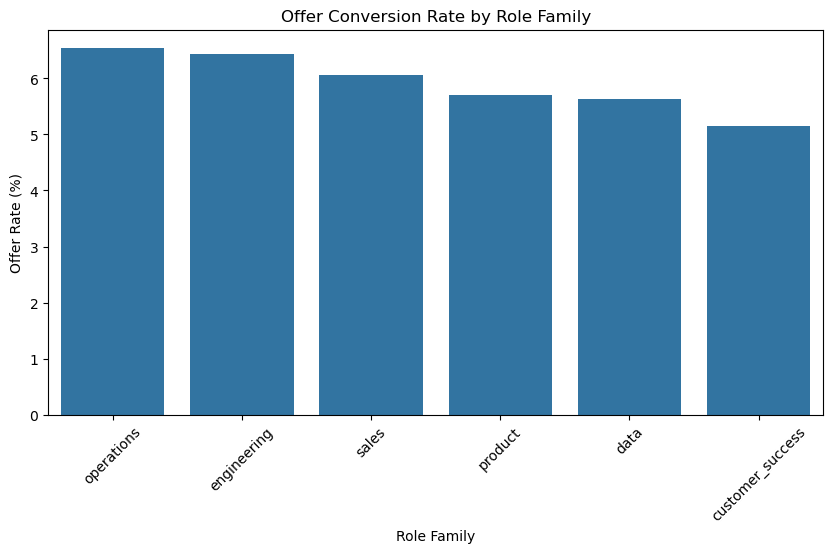

In [102]:
# Role Family vs Offer Rate

plt.figure(figsize=(10, 5))

sns.barplot(
    data=role_performance_summary,
    x='role_family',
    y='offer_rate'
)

plt.title('Offer Conversion Rate by Role Family')
plt.xlabel('Role Family')
plt.ylabel('Offer Rate (%)')
plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 6 — EDA FINDINGS & BUSINESS INSIGHTS
# ============================================================

## 1. Candidate Experience

The candidate pool contains candidates across multiple experience levels, 
with **10+ years representing the largest experience group**.

### Business Insight
The recruitment pipeline has a substantial pool of experienced candidates. 
However, experience alone should not be treated as the primary indicator of 
recruitment success.

---

## 2. Candidate Score

Candidate scores showed only a **modest relationship with recruitment outcomes**.

The analysis showed:

- Low Score → **6.11% offer rate**
- Medium Score → **6.20% offer rate**
- High Score → **6.50% offer rate**

### Business Insight
Higher candidate scores are associated with slightly higher offer conversion, 
but the difference is relatively small.

Recruiters should consider candidate score alongside experience, 
role requirements, job level, and other candidate attributes.

---

## 3. Salary and Job Seniority

The analysis showed a clear relationship between **job level and compensation**:

**Lead > Senior > Mid > Junior**

Average offer salaries:

| Job Level | Average Offer Salary |
|---|---:|
| Lead | $174,179.50 |
| Senior | $142,708.47 |
| Mid | $117,037.76 |
| Junior | $84,080.31 |

### Business Insight
Compensation increases consistently with job seniority.

This information can help recruitment and management teams benchmark 
salary expectations across different career levels.

---

## 4. Recruitment Sources

Job Boards generated the **largest application volume**, while 
Recruiter sourcing produced the **highest offer conversion rate**.

### Business Insight
Recruitment channels should not be evaluated solely by application volume.

Management should consider both **application volume and conversion efficiency** 
when allocating sourcing resources.

---

## 5. Role Family

Operations generated the largest recruitment volume:

- **7,443 applications**
- **487 offers**

Sales had the highest interview rate, while Customer Success had the 
lowest offer rate.

### Business Insight
Recruitment resources should be aligned with both **hiring demand and 
conversion efficiency**, rather than application volume alone.

---

## 6. Recruitment Cycle Time

The average **Application-to-Offer Time** was:

**28.70 days**

The observed range was:

- Minimum → **14 days**
- Maximum → **44 days**

### Business Insight
Approximately **29 days** can be used as a baseline for monitoring 
recruitment cycle efficiency.

### Data Limitation

The dataset does not contain a candidate joining or placement date.

Therefore, this metric represents **Application-to-Offer Time**, 
not true **Time-to-Hire**.

---

## 7. Monthly Recruitment Trend

Application volume peaked in **August 2025 with 855 applications** 
and generally declined afterward.

February 2026 recorded only **29 applications**.

### Business Insight
Recruitment activity shows a decline after the August 2025 peak.

Management should investigate whether this decline is related to:

- Changes in hiring demand
- Sourcing activity
- Seasonality
- Dataset coverage

### Data Quality Note

February 2026 appears to contain incomplete data and should not be 
directly compared with complete months unless the dataset is confirmed 
to contain the full month.

---

# Overall EDA Conclusion

The exploratory analysis provides several important insights into the 
recruitment pipeline.

The analysis shows that:

- Recruitment sources differ in both volume and conversion efficiency.
- Candidate score has only a modest relationship with offer conversion.
- Job seniority has a strong relationship with compensation.
- Operations represents the largest